# Chi-attractor investigation: when does chi=12 diverge?

Re-run TG N=256 Re=1000 at chi=11 (works, L2 ~ 4%) and chi=12 (broken, L2 ~ 76%), saving the MPS state at many intermediate times. Visualize the velocity field at each snapshot to see when the chi=12 attractor takes over.

Snapshots are dense at small t (to catch the onset of divergence) and sparser at large t (the long stable tail).

In [5]:
%matplotlib inline
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9
from lbm.collision import compute_moments
from tn.compression import compress_populations, decompress_populations
from tn_lbm.collision import collide_bgk_mps
from tn_lbm.streaming import stream_all_populations
from simulations.taylor_green import analytical_taylor_green
from experiments.stage3.common import Job
from experiments.stage3.test_cases import setup_test_case

## 1. Setup

In [11]:
N = 256
Re = 1000
u_char = 0.1
cutoff = 1e-10
taylor_order = 2

# Truncated to t=22000 — per-step time at chi=11/12 is ~0.7s, so running to
# t=64845 would take ~12h per chi. We don't need the long tail: the cluster
# JSONs already give us the final L2 values; this notebook is about the
# *onset* of divergence, which is fully captured below.
SNAPSHOT_TIMES = [0, 100, 250, 500, 1000, 2000, 4000, 7000, 10000,
                   15000, 22000]
# Subset for the velocity-map grid (8 cols would be too dense).
GRID_DISPLAY_TIMES = [0, 250, 1000, 4000, 10000, 22000]

# Build Job objects to leverage existing setup
def make_job(chi):
    return Job(job_id=0, test_case='tg', n=N, re=float(Re), u=u_char,
               cutoff=cutoff, chi=chi, taylor_order=taylor_order, mapping='snake')

spec_dummy = setup_test_case(make_job(64))
print(f'TG N={N} Re={Re}  nu={spec_dummy.nu:.5f}  tau={spec_dummy.tau:.4f}  nt={spec_dummy.nt}')
print(f'snapshot count: {len(SNAPSHOT_TIMES)}  grid display: {len(GRID_DISPLAY_TIMES)}')
print(f'truncating run at t={max(SNAPSHOT_TIMES)} (full nt would be {spec_dummy.nt})')

TG N=256 Re=1000  nu=0.02560  tau=0.5768  nt=64845
snapshot count: 11  grid display: 6
truncating run at t=22000 (full nt would be 64845)


## 2. Custom MPS runner with intermediate state saves

Modified copy of `run_mps` from `runners.py` — saves the full MPS state at requested time steps so we can decompress and inspect the velocity field at each.

In [12]:
def run_mps_with_snapshots(chi, snapshot_times):
    """Returns dict: {t: f_populations_dense}.
    Each entry is the *decompressed* population field at that timestep."""
    job = make_job(chi)
    spec = setup_test_case(job)
    mps_list, meta = compress_populations(spec.f_init, mapping='snake')
    saved = {}
    if 0 in snapshot_times:
        saved[0] = decompress_populations(mps_list, meta)
    t0 = time.time()
    last_snap = max(snapshot_times)
    for t in range(1, spec.nt + 1):
        # Mirror runners.py:run_mps:
        #   collide_bgk_mps returns just mps_list by default; needs return_moments=True for tuple.
        #   stream_all_populations takes (mps_list, metadata, lattice, max_bond, cyclic).
        mps_list = collide_bgk_mps(
            mps_list, D2Q9, spec.tau, spec.n,
            max_bond=chi, cutoff=cutoff, taylor_order=taylor_order)
        mps_list = stream_all_populations(
            mps_list, meta, D2Q9,
            max_bond=chi, cyclic=True)
        if t in snapshot_times:
            saved[t] = decompress_populations(mps_list, meta)
            print(f'  saved t={t}  (elapsed {time.time()-t0:.1f}s)')
        if t >= last_snap:
            break
    print(f'done in {time.time()-t0:.1f}s')
    return saved

## 3. Run chi=11 and chi=12

In [13]:
print('--- chi=11 (works) ---')
snaps_11 = run_mps_with_snapshots(chi=11, snapshot_times=SNAPSHOT_TIMES)
print()
print('--- chi=12 (broken) ---')
snaps_12 = run_mps_with_snapshots(chi=12, snapshot_times=SNAPSHOT_TIMES)

--- chi=11 (works) ---
  saved t=100  (elapsed 62.7s)
  saved t=250  (elapsed 159.9s)
  saved t=500  (elapsed 320.9s)
  saved t=1000  (elapsed 642.4s)
  saved t=2000  (elapsed 1288.2s)
  saved t=4000  (elapsed 2629.7s)
  saved t=7000  (elapsed 4690.2s)
  saved t=10000  (elapsed 6792.6s)
  saved t=15000  (elapsed 10346.3s)
  saved t=22000  (elapsed 15337.8s)
done in 15337.8s

--- chi=12 (broken) ---
  saved t=100  (elapsed 64.3s)
  saved t=250  (elapsed 165.9s)
  saved t=500  (elapsed 338.5s)
  saved t=1000  (elapsed 671.0s)
  saved t=2000  (elapsed 1335.5s)
  saved t=4000  (elapsed 2660.1s)
  saved t=7000  (elapsed 4698.1s)
  saved t=10000  (elapsed 6617.8s)
  saved t=15000  (elapsed 9794.2s)
  saved t=22000  (elapsed 14203.2s)
done in 14203.2s


## 4. Visualize velocity magnitude at each snapshot

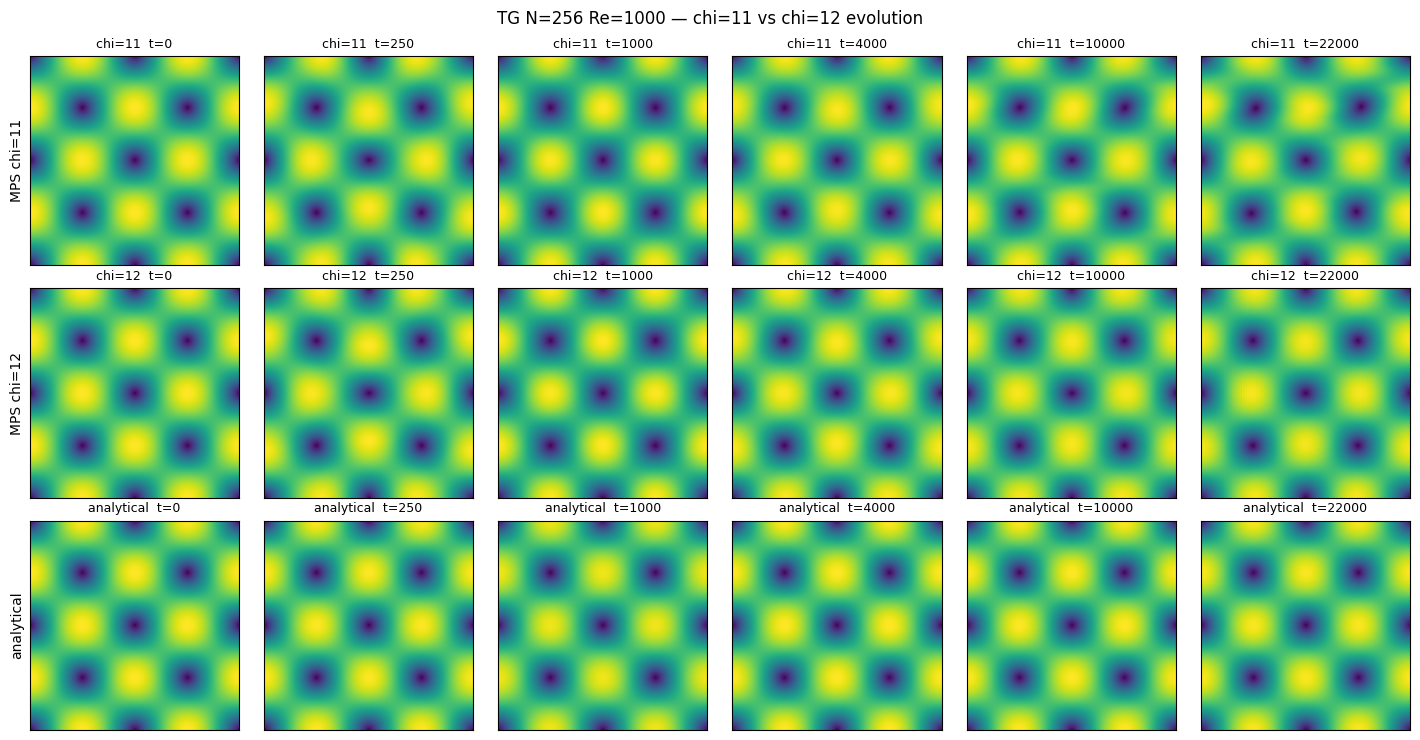

In [14]:
def speed_at(snap, lattice=D2Q9):
    _, u = compute_moments(lattice, snap)
    return np.sqrt(u[0]**2 + u[1]**2), u

nu = u_char * N / Re

fig, axes = plt.subplots(3, len(GRID_DISPLAY_TIMES), figsize=(2.4 * len(GRID_DISPLAY_TIMES), 7.5))
for col, t in enumerate(GRID_DISPLAY_TIMES):
    s11, _ = speed_at(snaps_11[t])
    s12, _ = speed_at(snaps_12[t])
    u_an = analytical_taylor_green(N, t=t, nu=nu, U0=u_char)
    s_an = np.sqrt(u_an[0]**2 + u_an[1]**2)
    vmax = max(s11.max(), s12.max(), s_an.max())

    axes[0, col].imshow(s11.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    axes[0, col].set_title(f'chi=11  t={t}', fontsize=9)
    axes[1, col].imshow(s12.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    axes[1, col].set_title(f'chi=12  t={t}', fontsize=9)
    axes[2, col].imshow(s_an.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    axes[2, col].set_title(f'analytical  t={t}', fontsize=9)
    for ax in axes[:, col]:
        ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('MPS chi=11', fontsize=10)
axes[1, 0].set_ylabel('MPS chi=12', fontsize=10)
axes[2, 0].set_ylabel('analytical', fontsize=10)
fig.suptitle(f'TG N={N} Re={Re} — chi=11 vs chi=12 evolution', fontsize=12)
fig.tight_layout()
fig.savefig('../results/stage3/figures/viz/tg_chi_attractor_evolution.pdf')
plt.show()

## 5. Quantify divergence: relative L2 vs analytical over time

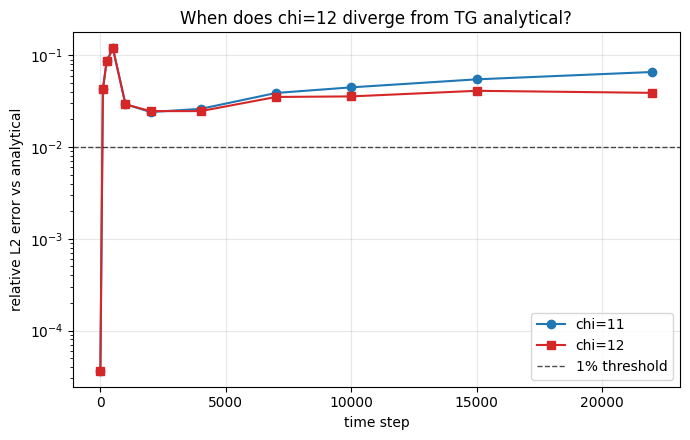

t=     0:  chi=11 L2=3.657e-05  |  chi=12 L2=3.657e-05
t=   100:  chi=11 L2=4.263e-02  |  chi=12 L2=4.263e-02
t=   250:  chi=11 L2=8.621e-02  |  chi=12 L2=8.621e-02
t=   500:  chi=11 L2=1.188e-01  |  chi=12 L2=1.188e-01
t=  1000:  chi=11 L2=2.929e-02  |  chi=12 L2=2.923e-02
t=  2000:  chi=11 L2=2.409e-02  |  chi=12 L2=2.464e-02
t=  4000:  chi=11 L2=2.608e-02  |  chi=12 L2=2.465e-02
t=  7000:  chi=11 L2=3.885e-02  |  chi=12 L2=3.515e-02
t= 10000:  chi=11 L2=4.475e-02  |  chi=12 L2=3.565e-02
t= 15000:  chi=11 L2=5.471e-02  |  chi=12 L2=4.103e-02
t= 22000:  chi=11 L2=6.579e-02  |  chi=12 L2=3.897e-02


In [15]:
def rel_l2(u_a, u_b):
    d = u_a - u_b
    return float(np.sqrt(np.sum(d**2) / (np.sum(u_b**2) + 1e-30)))

errs_11, errs_12 = [], []
for t in SNAPSHOT_TIMES:
    _, u11 = speed_at(snaps_11[t])
    _, u12 = speed_at(snaps_12[t])
    u_an = analytical_taylor_green(N, t=t, nu=nu, U0=u_char)
    errs_11.append(rel_l2(u11, u_an))
    errs_12.append(rel_l2(u12, u_an))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(SNAPSHOT_TIMES, errs_11, 'o-', color='C0', label='chi=11')
ax.plot(SNAPSHOT_TIMES, errs_12, 's-', color='C3', label='chi=12')
ax.axhline(0.01, color='black', linestyle='--', linewidth=1, alpha=0.7, label='1% threshold')
ax.set_xlabel('time step')
ax.set_ylabel('relative L2 error vs analytical')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title('When does chi=12 diverge from TG analytical?')
fig.tight_layout()
fig.savefig('../results/stage3/figures/viz/tg_chi_attractor_l2_vs_t.pdf')
plt.show()

for t, e11, e12 in zip(SNAPSHOT_TIMES, errs_11, errs_12):
    print(f't={t:>6}:  chi=11 L2={e11:.3e}  |  chi=12 L2={e12:.3e}')

## 6. Extended chi=12 run to full simulation time


In [17]:
# Dense snapshots — especially in the 22k..50k window where any transition
# would emerge. Snapshot saves are cheap (~10ms each); cost is the time
# evolution between snapshots, which is the same regardless.
SNAPSHOT_TIMES_FULL = [
    0, 1000, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22000,
    25000, 28000, 31000, 34000, 37000, 40000, 44000, 48000, 52000, 56000, 60000, 64845,
]
print(f'extended run: {len(SNAPSHOT_TIMES_FULL)} snapshots, max t = {max(SNAPSHOT_TIMES_FULL)}')

print('--- chi=12 (full run, ~12h) ---')
snaps_12_full = run_mps_with_snapshots(chi=12, snapshot_times=SNAPSHOT_TIMES_FULL)

extended run: 23 snapshots, max t = 64845
--- chi=12 (full run, ~12h) ---
  saved t=1000  (elapsed 679.9s)
  saved t=2500  (elapsed 1689.4s)
  saved t=5000  (elapsed 3349.1s)
  saved t=7500  (elapsed 4951.2s)
  saved t=10000  (elapsed 6532.9s)
  saved t=12500  (elapsed 8106.1s)
  saved t=15000  (elapsed 9669.0s)
  saved t=17500  (elapsed 11191.5s)
  saved t=20000  (elapsed 12715.2s)
  saved t=22000  (elapsed 13934.5s)
  saved t=25000  (elapsed 15760.3s)
  saved t=28000  (elapsed 17580.9s)
  saved t=31000  (elapsed 19390.3s)
  saved t=34000  (elapsed 21207.0s)
  saved t=37000  (elapsed 23018.8s)
  saved t=40000  (elapsed 24836.7s)
  saved t=44000  (elapsed 27248.6s)
  saved t=48000  (elapsed 31092.2s)
  saved t=52000  (elapsed 33482.8s)
  saved t=56000  (elapsed 38428.1s)
  saved t=60000  (elapsed 40829.8s)
  saved t=64845  (elapsed 85039.2s)
done in 85039.2s


snapshots saved to ../results/stage3/chi12_full_snapshots.pkl
t=     0: L2 vs analytical = 3.657e-05
t=  1000: L2 vs analytical = 2.923e-02
t=  2500: L2 vs analytical = 1.103e-01
t=  5000: L2 vs analytical = 3.264e-02
t=  7500: L2 vs analytical = 8.313e-02
t= 10000: L2 vs analytical = 3.565e-02
t= 12500: L2 vs analytical = 5.681e-02
t= 15000: L2 vs analytical = 4.103e-02
t= 17500: L2 vs analytical = 3.142e-02
t= 20000: L2 vs analytical = 4.488e-02
t= 22000: L2 vs analytical = 3.897e-02
t= 25000: L2 vs analytical = 3.361e-02
t= 28000: L2 vs analytical = 3.240e-02
t= 31000: L2 vs analytical = 2.970e-02
t= 34000: L2 vs analytical = 3.085e-02
t= 37000: L2 vs analytical = 2.920e-02
t= 40000: L2 vs analytical = 2.678e-02
t= 44000: L2 vs analytical = 3.049e-02
t= 48000: L2 vs analytical = 2.518e-02
t= 52000: L2 vs analytical = 2.788e-02
t= 56000: L2 vs analytical = 3.378e-02
t= 60000: L2 vs analytical = 3.742e-02
t= 64845: L2 vs analytical = 4.783e-02


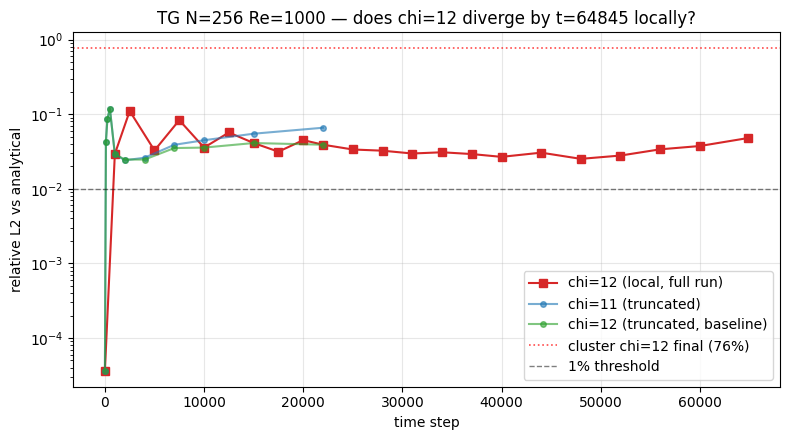

In [18]:
# Visualise the full-length chi=12 trajectory: L2 vs analytical, plus velocity-magnitude maps.

import pickle
# Persist the raw snapshots so we don't lose them if the kernel crashes
with open('../results/stage3/chi12_full_snapshots.pkl', 'wb') as fh:
    pickle.dump({'snapshot_times': SNAPSHOT_TIMES_FULL,
                  'snaps_12_full': snaps_12_full}, fh)
print('snapshots saved to ../results/stage3/chi12_full_snapshots.pkl')

# Compute L2 vs analytical at each snapshot
errs_12_full = []
for t in SNAPSHOT_TIMES_FULL:
    _, u12 = speed_at(snaps_12_full[t])
    u_an = analytical_taylor_green(N, t=t, nu=nu, U0=u_char)
    errs_12_full.append(rel_l2(u12, u_an))
    print(f't={t:>6}: L2 vs analytical = {errs_12_full[-1]:.3e}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(SNAPSHOT_TIMES_FULL, errs_12_full, 's-', color='C3', markersize=6,
        label='chi=12 (local, full run)')
# overlay the truncated chi=11/12 for context
ax.plot(SNAPSHOT_TIMES, errs_11, 'o-', color='C0', markersize=4, alpha=0.6,
        label='chi=11 (truncated)')
ax.plot(SNAPSHOT_TIMES, errs_12, 'o-', color='C2', markersize=4, alpha=0.6,
        label='chi=12 (truncated, baseline)')
ax.axhline(0.76, color='red', linestyle=':', linewidth=1.2, alpha=0.7,
           label='cluster chi=12 final (76%)')
ax.axhline(0.01, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label='1% threshold')
ax.set_xlabel('time step')
ax.set_ylabel('relative L2 vs analytical')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'TG N={N} Re={Re} — does chi=12 diverge by t=64845 locally?')
fig.tight_layout()
fig.savefig('../results/stage3/figures/viz/tg_chi_attractor_extended.pdf')
plt.show()

In [ ]:
# Velocity-magnitude maps of the extended chi=12 run at representative times.
# If a wrong attractor were present we'd see the flow topology change
# (horizontal stripes, blobs etc, like the cluster's chi=12 case).
# If the TG 4x4 vortex grid is preserved throughout, chi=12 stays in the
# physical attractor locally.

display_times = [0, 5000, 15000, 28000, 48000, 64845]   # must be in SNAPSHOT_TIMES_FULL
assert all(t in snaps_12_full for t in display_times), "pick times from SNAPSHOT_TIMES_FULL"

fig, axes = plt.subplots(2, len(display_times), figsize=(2.4 * len(display_times), 5.5))
for col, t in enumerate(display_times):
    s12, _ = speed_at(snaps_12_full[t])
    u_an = analytical_taylor_green(N, t=t, nu=nu, U0=u_char)
    s_an = np.sqrt(u_an[0]**2 + u_an[1]**2)
    vmax = max(s12.max(), s_an.max())
    axes[0, col].imshow(s12.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    axes[0, col].set_title(f'chi=12  t={t}', fontsize=9)
    axes[1, col].imshow(s_an.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    axes[1, col].set_title(f'analytical  t={t}', fontsize=9)
    for ax in axes[:, col]:
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('MPS chi=12', fontsize=10)
axes[1, 0].set_ylabel('analytical', fontsize=10)
fig.suptitle(f'TG N={N} Re={Re} chi=12 — full-time evolution (local)', fontsize=11)
fig.tight_layout()
fig.savefig('../results/stage3/figures/viz/tg_chi12_full_local_fields.pdf')
plt.show()